In [14]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)

In [16]:
cleaned_path = r"c:\Users\PC\OneDrive\Desktop\tb2\nyc-taxi\data\processed\yellow_tripdata_2026_clean.parquet"

try:
    df_clean = pl.read_parquet(cleaned_path)
except FileNotFoundError:
    print(f" ERROR: No se encontró el archivo en {cleaned_path}")
    raise

print(f"\n{'='*80}")
print(f"INFORMACIÓN BÁSICA - DATOS LIMPIOS")
print(f"{'='*80}")
print(f"Forma: {df_clean.shape[0]:,} filas × {df_clean.shape[1]} columnas")
print(f"Tamaño en memoria: {df_clean.estimated_size() / 1024 / 1024:.2f} MB")

print(f"\n{'='*80}")
print(f"ESQUEMA DEL DATASET")
print(f"{'='*80}")
schema = df_clean.schema
for i, (col_name, col_type) in enumerate(schema.items(), 1):
    print(f"{i:2}. {col_name:30} {str(col_type):20}")

print(f"\n{'='*80}")
print(f"PRIMERAS 5 FILAS")
print(f"{'='*80}")
print(df_clean.head(5))


INFORMACIÓN BÁSICA - DATOS LIMPIOS
Forma: 10,463,178 filas × 17 columnas
Tamaño en memoria: 1350.36 MB

ESQUEMA DEL DATASET
 1. VendorID                       Int32               
 2. tpep_pickup_datetime           Datetime(time_unit='us', time_zone='UTC')
 3. tpep_dropoff_datetime          Datetime(time_unit='us', time_zone='UTC')
 4. PULocationID                   Int32               
 5. DOLocationID                   Int32               
 6. pu_borough                     String              
 7. pu_zone                        String              
 8. pu_service_zone                String              
 9. do_borough                     String              
10. do_zone                        String              
11. do_service_zone                String              
12. trip_distance                  Float64             
13. fare_amount                    Float64             
14. trip_duration_minutes          Int64               
15. pickup_hour                    Int32         

In [18]:
expected_types = {
    'VendorID': pl.Int32,
    'tpep_pickup_datetime': pl.Datetime,
    'tpep_dropoff_datetime': pl.Datetime,
    'passenger_count': pl.Int32,
    'trip_distance': pl.Float64,
    'RatecodeID': pl.Int32,
    'PULocationID': pl.Int32,
    'DOLocationID': pl.Int32,
    'payment_type': pl.Int32,
    'fare_amount': pl.Float64,
    'extra': pl.Float64,
    'mta_tax': pl.Float64,
    'tip_amount': pl.Float64,
    'tolls_amount': pl.Float64,
    'total_amount': pl.Float64,
}

print(f"{'='*80}")
print(f"VALIDACIÓN DE TIPOS DE DATOS")
print(f"{'='*80}\n")

type_issues = []
for col, expected_type in expected_types.items():
    if col not in df_clean.columns:
        print(f" FALTA COLUMNA: {col}")
        type_issues.append(f"Columna {col} no existe")
        continue
    
    actual_type = df_clean.schema[col]
    if actual_type == expected_type:
        print(f" {col:30} : {str(actual_type):20}")
    else:
        print(f"{col:30} : {str(actual_type):20} (esperado: {str(expected_type)})")
        type_issues.append(f"Tipo incorrecto en {col}: {actual_type} vs {expected_type}")

if type_issues:
    print(f"\n Se encontraron {len(type_issues)} casualidades:")
    for issue in type_issues:
        print(f"  - {issue}")
else:
    print(f"\n Todos los tipos de datos son correctos")

VALIDACIÓN DE TIPOS DE DATOS

 VendorID                       : Int32               
 tpep_pickup_datetime           : Datetime(time_unit='us', time_zone='UTC')
 tpep_dropoff_datetime          : Datetime(time_unit='us', time_zone='UTC')
 FALTA COLUMNA: passenger_count
 trip_distance                  : Float64             
 FALTA COLUMNA: RatecodeID
 PULocationID                   : Int32               
 DOLocationID                   : Int32               
 FALTA COLUMNA: payment_type
 fare_amount                    : Float64             
 FALTA COLUMNA: extra
 FALTA COLUMNA: mta_tax
 FALTA COLUMNA: tip_amount
 FALTA COLUMNA: tolls_amount
 FALTA COLUMNA: total_amount

 Se encontraron 8 casualidades:
  - Columna passenger_count no existe
  - Columna RatecodeID no existe
  - Columna payment_type no existe
  - Columna extra no existe
  - Columna mta_tax no existe
  - Columna tip_amount no existe
  - Columna tolls_amount no existe
  - Columna total_amount no existe


In [20]:
print(f"{'='*80}")
print(f"ANÁLISIS DE VALORES NULL")
print(f"{'='*80}\n")

null_counts = df_clean.select(
    [pl.col(col).null_count().alias(col) for col in df_clean.columns]
).to_dict(as_series=False)

total_rows = df_clean.shape[0]
null_data = []
critical_nulls = []

for col in df_clean.columns:
    null_count = null_counts[col][0]
    null_pct = (null_count / total_rows) * 100 if total_rows > 0 else 0
    null_data.append({
        'Columna': col,
        'NULL_Count': null_count,
        'NULL_%': f"{null_pct:.4f}%"
    })
    
    if null_count > 0:
        critical_nulls.append((col, null_count, null_pct))

null_df = pd.DataFrame(null_data)
print(null_df.to_string(index=False))

if critical_nulls:
    print(f"\n Se encontraron {len(critical_nulls)} columnas con valores NULL:")
    for col, count, pct in critical_nulls:
        print(f"  - {col:30} : {count:,} NULLs ({pct:.4f}%)")
    
    rows_with_null = df_clean.filter(
        pl.any_horizontal([pl.col(col).is_null() for col in df_clean.columns])
    ).shape[0]
    
    print(f"\n  Total de filas con al menos 1 NULL: {rows_with_null:,} ({(rows_with_null/total_rows)*100:.2f}%)")
    print(f"\nPROBLEMA: Se esperaba 0 valores NULL en datos limpios")
    null_issue = True
else:
    null_issue = False

ANÁLISIS DE VALORES NULL

              Columna  NULL_Count  NULL_%
             VendorID           0 0.0000%
 tpep_pickup_datetime           0 0.0000%
tpep_dropoff_datetime           0 0.0000%
         PULocationID           0 0.0000%
         DOLocationID           0 0.0000%
           pu_borough           0 0.0000%
              pu_zone           0 0.0000%
      pu_service_zone           0 0.0000%
           do_borough           0 0.0000%
              do_zone           0 0.0000%
      do_service_zone           0 0.0000%
        trip_distance           0 0.0000%
          fare_amount           0 0.0000%
trip_duration_minutes           0 0.0000%
          pickup_hour           0 0.0000%
   pickup_day_of_week           0 0.0000%
         pickup_month           0 0.0000%


In [21]:
df_pd = df_clean.to_pandas()

outlier_summary = []

Q1_dur = df_pd['trip_duration_minutes'].quantile(0.25)
Q3_dur = df_pd['trip_duration_minutes'].quantile(0.75)
IQR_dur = Q3_dur - Q1_dur
lower_bound_dur = Q1_dur - 1.5 * IQR_dur
upper_bound_dur = Q3_dur + 1.5 * IQR_dur

outliers_dur = df_pd[
    (df_pd['trip_duration_minutes'] < lower_bound_dur) | 
    (df_pd['trip_duration_minutes'] > upper_bound_dur)
]

print(f"1. TRIP DURATION (minutos)")
print(f"   Q1: {Q1_dur:.2f}, Q3: {Q3_dur:.2f}, IQR: {IQR_dur:.2f}")
print(f"   Rango válido: {lower_bound_dur:.2f} - {upper_bound_dur:.2f}")
print(f"   Outliers: {len(outliers_dur):,} ({(len(outliers_dur)/len(df_pd))*100:.2f}%)")
outlier_summary.append(('trip_duration', len(outliers_dur)))

Q1_dist = df_pd['trip_distance'].quantile(0.25)
Q3_dist = df_pd['trip_distance'].quantile(0.75)
IQR_dist = Q3_dist - Q1_dist
upper_bound_dist = Q3_dist + 1.5 * IQR_dist

outliers_dist = df_pd[df_pd['trip_distance'] > upper_bound_dist]

print(f"\n2. TRIP DISTANCE (millas)")
print(f"   Q1: {Q1_dist:.2f}, Q3: {Q3_dist:.2f}, IQR: {IQR_dist:.2f}")
print(f"   Límite superior: {upper_bound_dist:.2f}")
print(f"   Outliers: {len(outliers_dist):,} ({(len(outliers_dist)/len(df_pd))*100:.2f}%)")
outlier_summary.append(('trip_distance', len(outliers_dist)))

Q1_fare = df_pd['fare_amount'].quantile(0.25)
Q3_fare = df_pd['fare_amount'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare
lower_bound_fare = Q1_fare - 1.5 * IQR_fare
upper_bound_fare = Q3_fare + 1.5 * IQR_fare

outliers_fare = df_pd[
    (df_pd['fare_amount'] < lower_bound_fare) | 
    (df_pd['fare_amount'] > upper_bound_fare)
]

print(f"\n3. FARE AMOUNT ($)")
print(f"   Q1: {Q1_fare:.2f}, Q3: {Q3_fare:.2f}, IQR: {IQR_fare:.2f}")
print(f"   Rango válido: {lower_bound_fare:.2f} - {upper_bound_fare:.2f}")
print(f"   Outliers: {len(outliers_fare):,} ({(len(outliers_fare)/len(df_pd))*100:.2f}%)")
outlier_summary.append(('fare_amount', len(outliers_fare)))

total_outliers = sum([x[1] for x in outlier_summary])
print(f"\n Total de filas con al least 1 outlier (IQR): {total_outliers:,} ({(total_outliers/len(df_pd))*100:.2f}%)")

1. TRIP DURATION (minutos)
   Q1: 8.00, Q3: 21.00, IQR: 13.00
   Rango válido: -11.50 - 40.50
   Outliers: 632,882 (6.05%)

2. TRIP DISTANCE (millas)
   Q1: 1.09, Q3: 3.87, IQR: 2.78
   Límite superior: 8.04
   Outliers: 1,180,103 (11.28%)

3. FARE AMOUNT ($)
   Q1: 10.00, Q3: 26.75, IQR: 16.75
   Rango válido: -15.12 - 51.88
   Outliers: 656,562 (6.27%)

 Total de filas con al least 1 outlier (IQR): 2,469,547 (23.60%)


In [22]:
print(f"{'='*80}")
print(f"VALIDACIÓN DE LÓGICA DE NEGOCIO")
print(f"{'='*80}\n")

business_issues = []

negative_or_zero_duration = (df_pd['trip_duration_minutes'] <= 0).sum()
print(f"1. TRIP DURATION > 0 minutos")
print(f"   Violaciones: {negative_or_zero_duration:,} ({(negative_or_zero_duration/len(df_pd))*100:.4f}%)")
if negative_or_zero_duration > 0:
    business_issues.append(('trip_duration ≤ 0', negative_or_zero_duration))
    print(f"   PROBLEMA: Hay viajes con duración no positiva")

negative_distance = (df_pd['trip_distance'] < 0).sum()
print(f"\n2. TRIP DISTANCE ≥ 0 millas")
print(f"   Violaciones: {negative_distance:,} ({(negative_distance/len(df_pd))*100:.4f}%)")
if negative_distance > 0:
    business_issues.append(('trip_distance < 0', negative_distance))
    print(f"   PROBLEMA: Hay viajes con distancia negativa")

zero_distance = (df_pd['trip_distance'] == 0).sum()
print(f"   Distancia = 0: {zero_distance:,} ({(zero_distance/len(df_pd))*100:.4f}%)")

negative_fare = (df_pd['fare_amount'] < 0).sum()
print(f"\n3. FARE AMOUNT ≥ $0")
print(f"   Violaciones: {negative_fare:,} ({(negative_fare/len(df_pd))*100:.4f}%)")
if negative_fare > 0:
    business_issues.append(('fare_amount < 0', negative_fare))
    print(f"   PROBLEMA: Hay tarifas negativas")

invalid_times = (df_pd['tpep_dropoff_datetime'] <= df_pd['tpep_pickup_datetime']).sum()
print(f"\n4. DROPOFF > PICKUP (Lógica temporal)")
print(f"   Violaciones: {invalid_times:,} ({(invalid_times/len(df_pd))*100:.4f}%)")
if invalid_times > 0:
    business_issues.append(('dropoff ≤ pickup', invalid_times))
    print(f"  PROBLEMA: Hay viajes donde dropoff no es posterior a pickup")

date_start = pd.Timestamp('2026-01-01', tz='UTC')
date_end = pd.Timestamp('2026-03-31 23:59:59', tz='UTC')
out_of_range = ((df_pd['tpep_pickup_datetime'] < date_start) | (df_pd['tpep_pickup_datetime'] > date_end)).sum()
print(f"\n5. FECHA PICKUP en rango 2026-01-01 a 2026-03-31")
print(f"   Violaciones: {out_of_range:,} ({(out_of_range/len(df_pd))*100:.4f}%)")
if out_of_range > 0:
    business_issues.append(('fecha fuera de rango', out_of_range))
    print(f"   PROBLEMA: Hay viajes fuera del rango de fechas esperado")


same_location = (df_pd['PULocationID'] == df_pd['DOLocationID']).sum()
print(f"\n6. UBICACIONES DIFERENTES (PU != DO)")
print(f"   Pickup = Dropoff: {same_location:,} ({(same_location/len(df_pd))*100:.2f}%)")
print(f"   Nota: Estos viajes son válidos (pick & drop en misma zona)")

if business_issues:
    print(f"\n{'='*80}")
    print(f"RESUMEN DE PROBLEMAS DE LÓGICA DE NEGOCIO")
    print(f"{'='*80}")
    for issue, count in business_issues:
        print(f"  - {issue:30} : {count:,} filas")
else:
    print(f"\nTodos los datos cumplen con la lógica de negocio esperada")

VALIDACIÓN DE LÓGICA DE NEGOCIO

1. TRIP DURATION > 0 minutos
   Violaciones: 0 (0.0000%)

2. TRIP DISTANCE ≥ 0 millas
   Violaciones: 0 (0.0000%)
   Distancia = 0: 0 (0.0000%)

3. FARE AMOUNT ≥ $0
   Violaciones: 0 (0.0000%)

4. DROPOFF > PICKUP (Lógica temporal)
   Violaciones: 0 (0.0000%)

5. FECHA PICKUP en rango 2026-01-01 a 2026-03-31
   Violaciones: 0 (0.0000%)

6. UBICACIONES DIFERENTES (PU != DO)
   Pickup = Dropoff: 391,709 (3.74%)
   Nota: Estos viajes son válidos (pick & drop en misma zona)

Todos los datos cumplen con la lógica de negocio esperada


In [23]:
print(f"\n{'='*80}")
print(f"REPORTE FINAL DE CALIDAD DE DATOS")
print(f"{'='*80}\n")

all_issues = []

if null_issue:
    all_issues.extend([(col, count, pct) for col, count, pct in critical_nulls])

if business_issues:
    all_issues.extend([(issue[0], issue[1], (issue[1]/len(df_pd))*100) for issue in business_issues])

print(f"Fecha de validación: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total de filas analizadas: {len(df_pd):,}")
print(f"Total de columnas: {df_clean.shape[1]}")
print(f"Tamaño total: {df_clean.estimated_size() / 1024 / 1024:.2f} MB")

print(f"\n{'─'*80}")
print(f"RESUMEN DE VALIDACIÓN")
print(f"{'─'*80}")

print(f"\n1. VALORES NULL")
if null_issue:
    print(f"   FALLO: Se encontraron {len(critical_nulls)} columnas con NULLs")
    for col, count, pct in critical_nulls:
        print(f"     - {col}: {count:,} NULLs ({pct:.4f}%)")
else:
    print(f"   APROBADO: No hay valores NULL")

print(f"\n2. LÓGICA DE NEGOCIO")
if business_issues:
    print(f"   FALLO: Se encontraron {len(business_issues)} violaciones")
    for issue, count in business_issues:
        pct = (count/len(df_pd))*100
        print(f"     - {issue}: {count:,} filas ({pct:.4f}%)")
else:
    print(f"   APROBADO: Todos los datos cumplen reglas de negocio")

print(f"\n3. OUTLIERS (IQR)")
total_outlier_count = sum([x[1] for x in outlier_summary])
outlier_pct = (total_outlier_count/len(df_pd))*100
print(f"    INFO: {total_outlier_count:,} filas con outliers ({outlier_pct:.2f}%)")
print(f"   Nota: Los outliers son esperados y NO indican falta de limpieza")
for col, count in outlier_summary:
    pct = (count/len(df_pd))*100
    print(f"     - {col}: {count:,} ({pct:.2f}%)")

print(f"\n4. ESTRUCTURA Y TRANSFORMACIÓN")
print(f"   INFO: Go ha transformado los datos:")
print(f"     - Agregó columnas de lookup (borough, zone, service_zone)")
print(f"     - Pre-calculó trip_duration_minutes")
print(f"     - Pre-calculó features temporales (hour, day_of_week, month)")
print(f"    Transformación completada exitosamente")

print(f"\n{'─'*80}")
print(f"CONCLUSIÓN")
print(f"{'─'*80}\n")

if null_issue or business_issues:
    print(f" LOS DATOS NO ESTÁN COMPLETAMENTE LIMPIOS")
    print(f"\nProblemas encontrados:")
    if null_issue:
        print(f"   Valores NULL aún presentes")
    if business_issues:
        print(f"   Violaciones de lógica de negocio")
    
    print(f"\n{'='*80}")
    print(f"ANÁLISIS DETENIDO - SE REQUIERE LIMPIEZA ADICIONAL")
    print(f"{'='*80}\n")
    
    print(f"ACCIONES RECOMENDADAS:")
    if null_issue:
        print(f"\n1. ELIMINAR FILAS CON NULL")
        for col, count, pct in critical_nulls:
            print(f"   - Columna '{col}': {count:,} filas tienen NULL")
    
    if business_issues:
        print(f"\n2. ELIMINAR FILAS CON VIOLACIONES DE NEGOCIO")
        for issue, count in business_issues:
            print(f"   - {issue}: {count:,} filas deben ser eliminadas")
    
    print(f"\nModifica el código Go en clean.go para:")
    print(f"  • Descartar filas con NULL en columnas críticas")
    print(f"  • Validar que trip_duration > 0")
    print(f"  • Validar que trip_distance >= 0 y > 0 (para viajes reales)")
    print(f"  • Validar que fare_amount >= 0")
    
    print(f"\n{'='*80}")
    raise Exception("Limpieza incompleta - Se requieren correcciones en Go")

else:
    print(f" LOS DATOS ESTÁN LIMPIOS Y LISTOS PARA ANÁLISIS ML")
    print(f"\nEstadísticas de calidad:")
    print(f"   Filas válidas: {len(df_pd):,}")
    print(f"   Columnas: {df_clean.shape[1]}")
    print(f"   Valores NULL: 0")
    print(f"   Violaciones de negocio: 0")
    print(f"   Outliers (IQR): {total_outlier_count:,} ({outlier_pct:.2f}%)")
    print(f"\nPuede proceder con el análisis de features y modelado.")
    
print(f"\n{'='*80}")


REPORTE FINAL DE CALIDAD DE DATOS

Fecha de validación: 2026-06-12 00:18:17
Total de filas analizadas: 10,463,178
Total de columnas: 17
Tamaño total: 1350.36 MB

────────────────────────────────────────────────────────────────────────────────
RESUMEN DE VALIDACIÓN
────────────────────────────────────────────────────────────────────────────────

1. VALORES NULL
   APROBADO: No hay valores NULL

2. LÓGICA DE NEGOCIO
   APROBADO: Todos los datos cumplen reglas de negocio

3. OUTLIERS (IQR)
    INFO: 2,469,547 filas con outliers (23.60%)
   Nota: Los outliers son esperados y NO indican falta de limpieza
     - trip_duration: 632,882 (6.05%)
     - trip_distance: 1,180,103 (11.28%)
     - fare_amount: 656,562 (6.27%)

4. ESTRUCTURA Y TRANSFORMACIÓN
   INFO: Go ha transformado los datos:
     - Agregó columnas de lookup (borough, zone, service_zone)
     - Pre-calculó trip_duration_minutes
     - Pre-calculó features temporales (hour, day_of_week, month)
    Transformación completada exitos

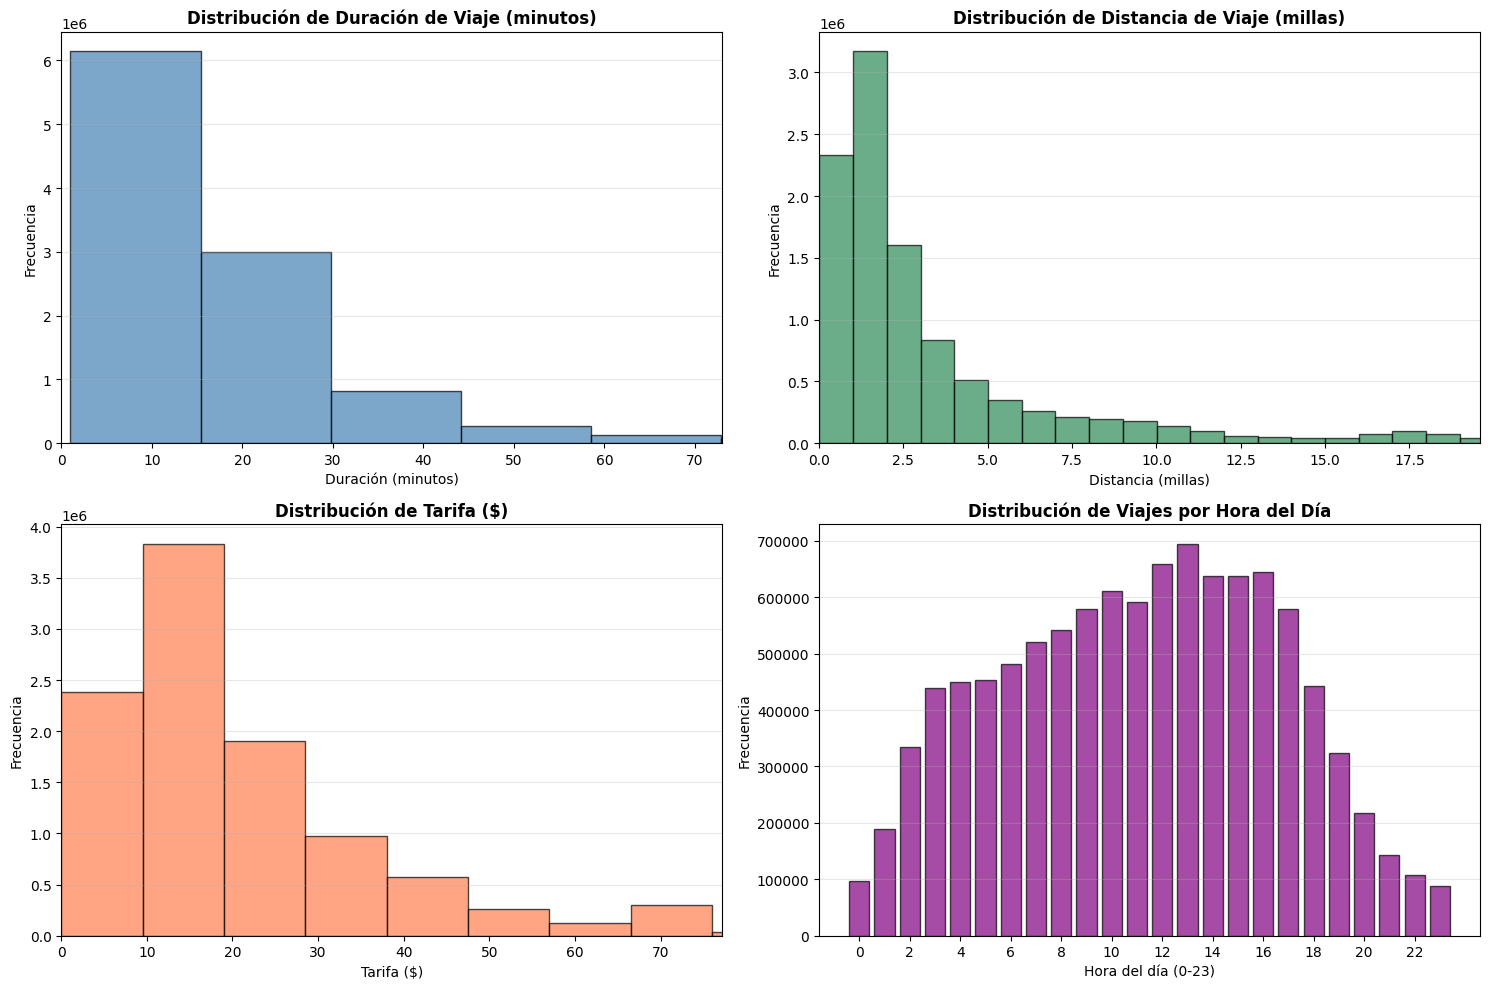

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].hist(df_pd['trip_duration_minutes'], bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribución de Duración de Viaje (minutos)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Duración (minutos)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].set_xlim(left=0, right=df_pd['trip_duration_minutes'].quantile(0.99))

axes[0, 1].hist(df_pd['trip_distance'], bins=100, color='seagreen', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribución de Distancia de Viaje (millas)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Distancia (millas)')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].set_xlim(left=0, right=df_pd['trip_distance'].quantile(0.99))

axes[1, 0].hist(df_pd['fare_amount'], bins=100, color='coral', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Distribución de Tarifa ($)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Tarifa ($)')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].set_xlim(left=0, right=df_pd['fare_amount'].quantile(0.99))

hour_dist = df_pd['pickup_hour'].value_counts().sort_index()
axes[1, 1].bar(hour_dist.index, hour_dist.values, color='purple', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Distribución de Viajes por Hora del Día', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Hora del día (0-23)')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

## Exploración para Random Forest

In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print(f"{'='*80}")
print(f"RANDOM FOREST - FEATURE IMPORTANCE ANALYSIS")
print(f"{'='*80}\n")

feature_cols = [
    'VendorID',
    'trip_distance',
    'fare_amount',
    'PULocationID',
    'DOLocationID',
    'pickup_hour',
    'pickup_day_of_week',
    'pickup_month'
]

target_col = 'trip_duration_minutes'

available_features = [col for col in feature_cols if col in df_pd.columns]
missing_features = [col for col in feature_cols if col not in df_pd.columns]

if missing_features:
    print(f" Features faltantes: {missing_features}")
    print(f"Features disponibles a usar: {available_features}\n")
else:
    print(f" Todas las features disponibles\n")

sample_size = min(500000, len(df_pd))
print(f"Tamaño de muestra para entrenamiento: {sample_size:,} filas")

df_sample = df_pd[available_features + [target_col]].sample(n=sample_size, random_state=42).copy()

df_sample_clean = df_sample.dropna()
print(f"Después de remover NaN: {len(df_sample_clean):,} filas\n")

X = df_sample_clean[available_features].values
y = df_sample_clean[target_col].values

print(f"Dividiendo datos (80% train, 20% test)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}\n")

print(f"Entrenando Random Forest Regressor...")
print(f"  • Parámetros: n_estimators=100, max_depth=15, n_jobs=-1\n")

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

rf.fit(X_train, y_train)

y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"{'─'*80}")
print(f"PERFORMANCE DEL MODELO")
print(f"{'─'*80}\n")

print(f"Training Set:")
print(f"  R² Score:  {train_r2:.4f} ({train_r2*100:.2f}%)")
print(f"  MAE:       {train_mae:.2f} minutos\n")

print(f"Test Set:")
print(f"  R² Score:  {test_r2:.4f} ({test_r2*100:.2f}%)")
print(f"  MAE:       {test_mae:.2f} minutos")
print(f"  RMSE:      {test_rmse:.2f} minutos\n")

print(f"{'─'*80}")
print(f"FEATURE IMPORTANCE RANKING")
print(f"{'─'*80}\n")

feature_importance = pd.DataFrame({
    'Feature': available_features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

feature_importance['Importance_Pct'] = (feature_importance['Importance'] * 100).round(3)
feature_importance['Cumulative_Pct'] = feature_importance['Importance_Pct'].cumsum().round(3)

print(feature_importance[['Feature', 'Importance_Pct', 'Cumulative_Pct']].to_string(index=True))

print(f"\n{'─'*80}")
print(f"ANÁLISIS DE UTILIDAD DE FEATURES")
print(f"{'─'*80}\n")

cumsum = feature_importance['Importance_Pct'].cumsum()

features_80_idx = (cumsum >= 80).idxmax()
features_80 = list(feature_importance.loc[:features_80_idx, 'Feature'])
print(f"✓ FEATURES ESENCIALES (80% de importancia):")
print(f"  {', '.join(features_80)}")

features_95_idx = (cumsum >= 95).idxmax()
features_95 = list(feature_importance.loc[:features_95_idx, 'Feature'])
print(f"\n✓ FEATURES RECOMENDADAS (95% de importancia):")
print(f"  {', '.join(features_95)}")

threshold_weak = 1.0 
weak_features = feature_importance[feature_importance['Importance_Pct'] < threshold_weak]['Feature'].tolist()
if weak_features:
    print(f"\n FEATURES DÉBILES (< 1% importancia) - Considerar descartar:")
    for feat in weak_features:
        imp = feature_importance[feature_importance['Feature'] == feat]['Importance_Pct'].values[0]
        print(f"  • {feat}: {imp:.3f}%")

print(f"\n{'─'*80}")
print(f"RECOMENDACIONES PARA EL MODELO")
print(f"{'─'*80}\n")

print(f"1. FEATURES A USAR DEFINITIVAMENTE:")
top_3 = list(feature_importance.head(3)['Feature'])
for i, feat in enumerate(top_3, 1):
    imp = feature_importance[feature_importance['Feature'] == feat]['Importance_Pct'].values[0]
    print(f"   {i}. {feat:20} ({imp:.2f}%)")

print(f"\n2. PERFORMANCE ESPERADO:")
print(f"   • R² Test: {test_r2*100:.1f}% (explica {test_r2*100:.1f}% de la varianza)")
print(f"   • Error MAE: ±{test_mae:.1f} minutos")
print(f"   • Error RMSE: ±{test_rmse:.1f} minutos")

print(f"\n3. CONFIGURACIÓN SUGERIDA:")
print(f"   • Usar {'todas' if len(features_95) == len(available_features) else f'{len(features_95)}/{len(available_features)}'} features")
print(f"   • n_estimators: 100-200")
print(f"   • max_depth: 12-20")
print(f"   • min_samples_leaf: 5-10")

print(f"\n{'='*80}")

RANDOM FOREST - FEATURE IMPORTANCE ANALYSIS

 Todas las features disponibles

Tamaño de muestra para entrenamiento: 500,000 filas
Después de remover NaN: 500,000 filas

Dividiendo datos (80% train, 20% test)...
Train: 400,000 | Test: 100,000

Entrenando Random Forest Regressor...
  • Parámetros: n_estimators=100, max_depth=15, n_jobs=-1

────────────────────────────────────────────────────────────────────────────────
PERFORMANCE DEL MODELO
────────────────────────────────────────────────────────────────────────────────

Training Set:
  R² Score:  0.4606 (46.06%)
  MAE:       2.80 minutos

Test Set:
  R² Score:  0.3369 (33.69%)
  MAE:       3.12 minutos
  RMSE:      18.37 minutos

────────────────────────────────────────────────────────────────────────────────
FEATURE IMPORTANCE RANKING
────────────────────────────────────────────────────────────────────────────────

              Feature  Importance_Pct  Cumulative_Pct
0         fare_amount          45.844          45.844
1       trip_

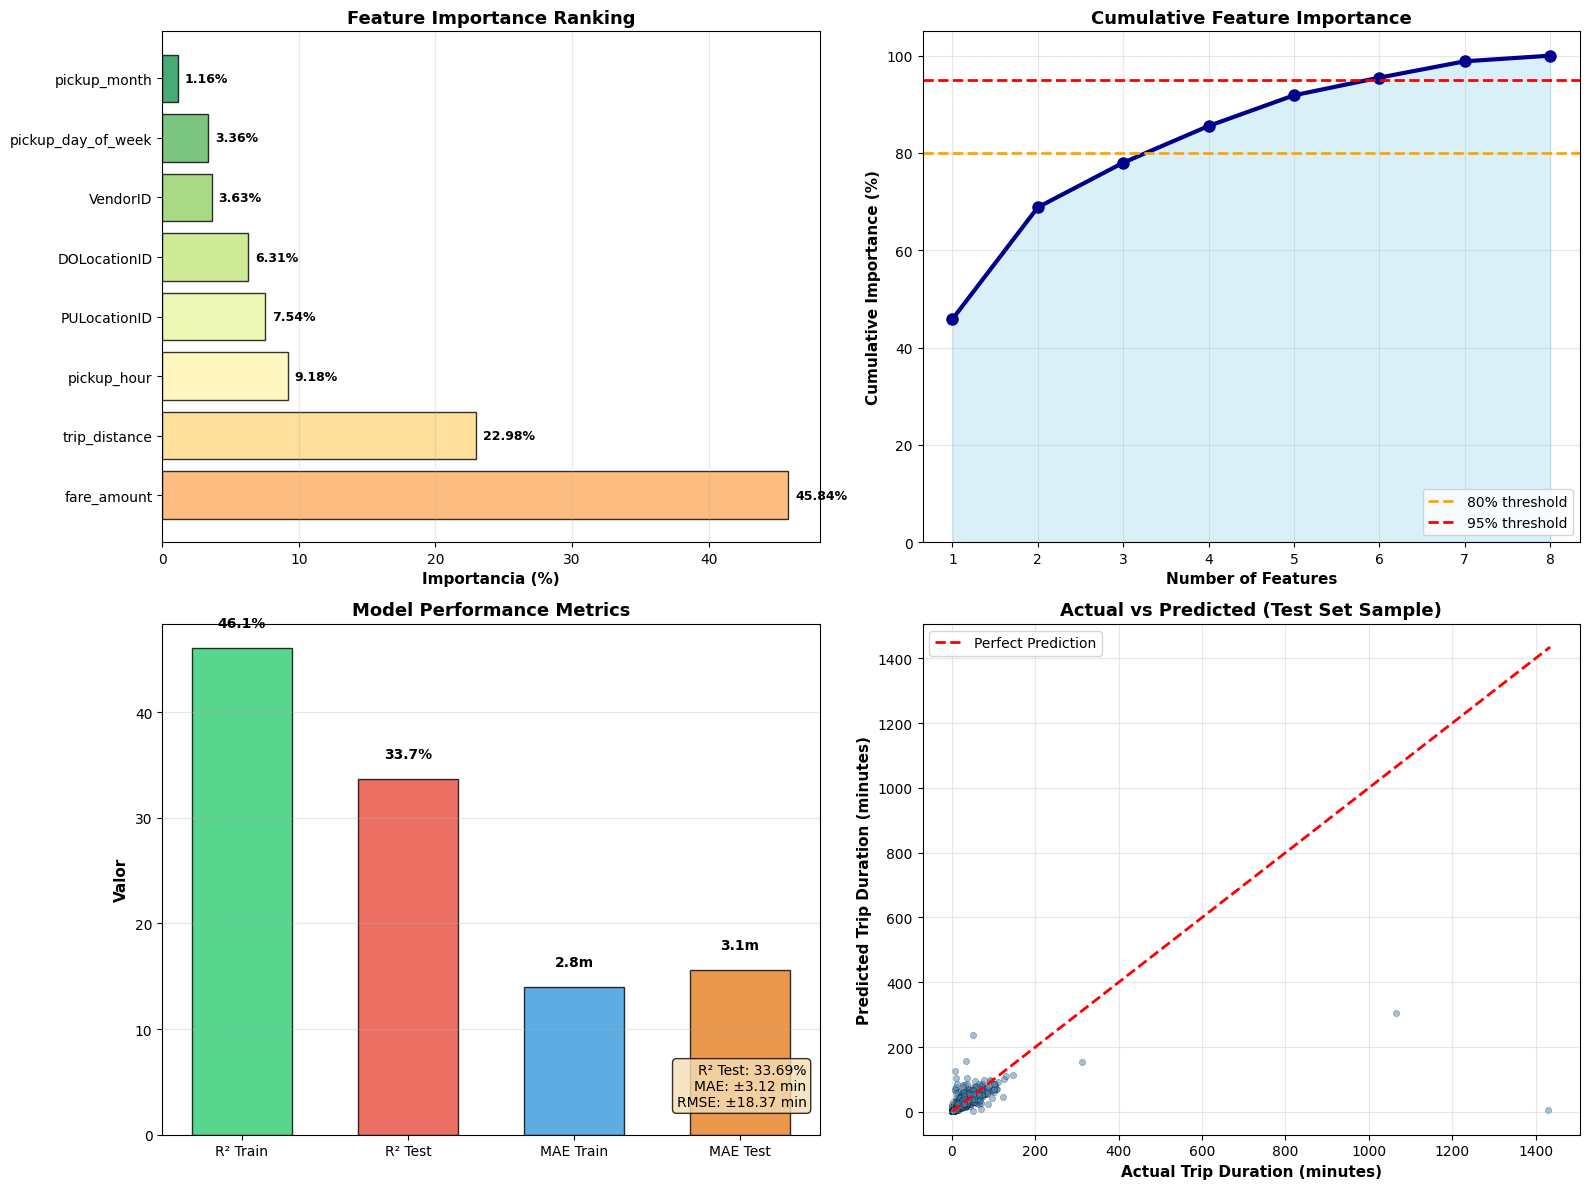

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax1 = axes[0, 0]
colors_imp = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(feature_importance)))
bars = ax1.barh(range(len(feature_importance)), feature_importance['Importance_Pct'], color=colors_imp, edgecolor='black', alpha=0.8)
ax1.set_yticks(range(len(feature_importance)))
ax1.set_yticklabels(feature_importance['Feature'], fontsize=10)
ax1.set_xlabel('Importancia (%)', fontsize=11, fontweight='bold')
ax1.set_title('Feature Importance Ranking', fontsize=13, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

for i, (feat, imp) in enumerate(zip(feature_importance['Feature'], feature_importance['Importance_Pct'])):
    ax1.text(imp + 0.5, i, f'{imp:.2f}%', va='center', fontweight='bold', fontsize=9)

ax2 = axes[0, 1]
cumsum_imp = feature_importance['Importance_Pct'].cumsum()
ax2.plot(range(len(feature_importance)), cumsum_imp, marker='o', linewidth=3, markersize=8, color='darkblue')
ax2.fill_between(range(len(feature_importance)), cumsum_imp, alpha=0.3, color='skyblue')
ax2.axhline(y=80, color='orange', linestyle='--', linewidth=2, label='80% threshold')
ax2.axhline(y=95, color='red', linestyle='--', linewidth=2, label='95% threshold')
ax2.set_xlabel('Number of Features', fontsize=11, fontweight='bold')
ax2.set_ylabel('Cumulative Importance (%)', fontsize=11, fontweight='bold')
ax2.set_title('Cumulative Feature Importance', fontsize=13, fontweight='bold')
ax2.set_xticks(range(len(feature_importance)))
ax2.set_xticklabels(range(1, len(feature_importance) + 1))
ax2.grid(alpha=0.3)
ax2.legend(loc='lower right', fontsize=10)
ax2.set_ylim(0, 105)

ax3 = axes[1, 0]
metrics = ['R² Train', 'R² Test', 'MAE Train', 'MAE Test']
values = [train_r2*100, test_r2*100, train_mae*5, test_mae*5] 
colors_perf = ['#2ecc71', '#e74c3c', '#3498db', '#e67e22']
bars = ax3.bar(metrics, values, color=colors_perf, edgecolor='black', alpha=0.8, width=0.6)
ax3.set_ylabel('Valor', fontsize=11, fontweight='bold')
ax3.set_title('Model Performance Metrics', fontsize=13, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

for i, (bar, val, metric) in enumerate(zip(bars, values, metrics)):
    if 'R²' in metric:
        label = f'{val:.1f}%'
    else:
        label = f'{val/5:.1f}m' 
    ax3.text(bar.get_x() + bar.get_width()/2., val + 2, label, ha='center', fontweight='bold', fontsize=10)

textstr = f'R² Test: {test_r2*100:.2f}%\nMAE: ±{test_mae:.2f} min\nRMSE: ±{test_rmse:.2f} min'
ax3.text(0.98, 0.05, textstr, transform=ax3.transAxes, fontsize=10, verticalalignment='bottom',
         horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax4 = axes[1, 1]
sample_indices = np.random.choice(len(y_test), size=min(5000, len(y_test)), replace=False)
ax4.scatter(y_test[sample_indices], y_pred_test[sample_indices], alpha=0.5, s=20, color='steelblue', edgecolors='black', linewidth=0.3)

min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
ax4.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

ax4.set_xlabel('Actual Trip Duration (minutes)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Predicted Trip Duration (minutes)', fontsize=11, fontweight='bold')
ax4.set_title('Actual vs Predicted (Test Set Sample)', fontsize=13, fontweight='bold')
ax4.grid(alpha=0.3)
ax4.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
print(f"\n{'='*80}")
print(f"ANÁLISIS DETALLADO DE FEATURES VS TARGET")
print(f"{'='*80}\n")

print(f"CORRELACIÓN CON TRIP_DURATION_MINUTES:\n")
correlations = []
for feat in available_features:
    corr = df_sample_clean[feat].corr(df_sample_clean[target_col])
    correlations.append((feat, corr))
    
correlations_sorted = sorted(correlations, key=lambda x: abs(x[1]), reverse=True)

corr_df = pd.DataFrame(correlations_sorted, columns=['Feature', 'Correlation'])
print(corr_df.to_string(index=False))

print(f"\n{'─'*80}")
print(f"ANÁLISIS POR TIPO DE FEATURE")
print(f"{'─'*80}\n")

numeric_features = ['trip_distance', 'fare_amount']
print(f"FEATURES NUMÉRICAS:")
for feat in numeric_features:
    if feat in available_features:
        corr = df_sample_clean[feat].corr(df_sample_clean[target_col])
        imp = feature_importance[feature_importance['Feature'] == feat]['Importance_Pct'].values[0]
        print(f"  • {feat:20} | Importancia: {imp:6.2f}% | Correlación: {corr:7.4f}")

categorical_features = ['VendorID', 'PULocationID', 'DOLocationID', 'pickup_hour', 'pickup_day_of_week', 'pickup_month']
print(f"\nFEATURES CATEGÓRICAS/TEMPORALES:")
for feat in categorical_features:
    if feat in available_features:
        imp = feature_importance[feature_importance['Feature'] == feat]['Importance_Pct'].values[0]
        unique_vals = df_sample_clean[feat].nunique()
        print(f"  • {feat:20} | Importancia: {imp:6.2f}% | Valores únicos: {unique_vals:3d}")

print(f"\n{'─'*80}")
print(f"ESTADÍSTICAS DESCRIPTIVAS POR FEATURE")
print(f"{'─'*80}\n")

for feat in available_features:
    print(f"{feat}:")
    print(f"  Min: {df_sample_clean[feat].min():.2f} | Max: {df_sample_clean[feat].max():.2f}")
    print(f"  Mean: {df_sample_clean[feat].mean():.2f} | Median: {df_sample_clean[feat].median():.2f}")
    print(f"  Std: {df_sample_clean[feat].std():.2f}")
    print()

print(f"{'='*80}")


ANÁLISIS DETALLADO DE FEATURES VS TARGET

CORRELACIÓN CON TRIP_DURATION_MINUTES:

           Feature  Correlation
     trip_distance     0.456675
       fare_amount     0.447542
      PULocationID    -0.076046
      DOLocationID    -0.068027
          VendorID    -0.065897
       pickup_hour    -0.063943
pickup_day_of_week    -0.030980
      pickup_month    -0.000639

────────────────────────────────────────────────────────────────────────────────
ANÁLISIS POR TIPO DE FEATURE
────────────────────────────────────────────────────────────────────────────────

FEATURES NUMÉRICAS:
  • trip_distance        | Importancia:  22.98% | Correlación:  0.4567
  • fare_amount          | Importancia:  45.84% | Correlación:  0.4475

FEATURES CATEGÓRICAS/TEMPORALES:
  • VendorID             | Importancia:   3.63% | Valores únicos:   3
  • PULocationID         | Importancia:   7.54% | Valores únicos: 255
  • DOLocationID         | Importancia:   6.31% | Valores únicos: 258
  • pickup_hour          | Imp